<a href="https://colab.research.google.com/github/mundundan-star/online-retail-customer-analytics/blob/main/6.0%20Predicting_Customer_Life_Time_Value_(CLTV).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install boto3

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import userdata
from sqlalchemy import create_engine, inspect, text

import boto3
import sys
import os
import importlib

engine = create_engine(userdata.get("NEON_DATABASE_URL"))

# Pulling data before August cutoff_date
query = """
SELECT *
FROM v_clean_sales_analytics
WHERE "InvoiceDate" < '2011-08-31'
"""
df = pd.read_sql(text(query), con = engine)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
# Intializing s3 with credentials

s3 = boto3.client(
   "s3",
   aws_access_key_id = userdata.get("AWS_ACCESS_KEY_ID"),
   aws_secret_access_key = userdata.get("AWS_SECRET_ACCESS_KEY"),
   region_name = "eu-north-1"
)

bucket_name = "sales-data-analytics-portfolio-2026"
local_filename = "feature_engineering.py"
location = "functions/feature_engineering.py"

s3.download_file(bucket_name, location, local_filename)
print(f'Successfully downloaded from {local_filename} file from {location} in AWS S3 {bucket_name}')

# getting features from df using feature_engineering function
import feature_engineering
importlib.reload(feature_engineering)
from feature_engineering import feature_engineering

Successfully downloaded from feature_engineering.py file from functions/feature_engineering.py in AWS S3 sales-data-analytics-portfolio-2026


In [ ]:
from datetime import datetime, timedelta

last_day_of_month = ['2010-12-31', '2011-01-31', '2011-02-28', '2011-03-31', '2011-04-30', '2011-05-31']

features_df = pd.DataFrame()

for date in last_day_of_month:

    X_data = df[df["InvoiceDate"] <= pd.to_datetime(date)]
    X_train = feature_engineering(X_data)


    y_data = df[(df["InvoiceDate"] > pd.to_datetime(date)) & (df["InvoiceDate"] <= (pd.to_datetime(date) + timedelta(days=120)))][["CustomerID","Revenue"]]
    y_data.columns = ["CustomerID","TargetRevenue"]
    y_data = y_data.groupby("CustomerID")["TargetRevenue"].sum().reset_index()

    feat_data = X_train.merge(y_data, on = "CustomerID", how = 'left').fillna(0)
    features_df = pd.concat([features_df, feat_data])

features_df = features_df[(features_df['TotalRevenue'] < features_df['TotalRevenue'].quantile(0.95))
& (features_df['Frequency'] < features_df['Frequency'].quantile(0.95)) ]

/content/feature_engineering.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
/content/feature_engineering.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
/content/feature_engineering.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydat

In [ ]:
features_df.info()
features_df.select_dtypes(exclude = ['object']).drop(["CustomerID", "CohortMonth"], axis =1).corr()

<class 'pandas.core.frame.DataFrame'>
Index: 10298 entries, 0 to 2717
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype    
---  ------                   --------------  -----    
 0   CustomerID               10298 non-null  float64  
 1   Frequency                10298 non-null  int64    
 2   ProductDiversity         10298 non-null  int64    
 3   AvgUnitPrice             10298 non-null  float64  
 4   AvgQuantity              10298 non-null  float64  
 5   AOV                      10298 non-null  float64  
 6   TotalRevenue             10298 non-null  float64  
 7   CohortMonth              10298 non-null  period[M]
 8   Recency                  10298 non-null  int64    
 9   Tenure                   10298 non-null  int64    
 10  ObservedLifeSpan         10298 non-null  int64    
 11  RecencyToTenure          10298 non-null  float64  
 12  ActivePurchaseDensity    10298 non-null  float64  
 13  LifetimePurchaseDensity  10298 non-null  float64  
 

,Frequency,ProductDiversity,AvgUnitPrice,AvgQuantity,AOV,TotalRevenue,Recency,Tenure,ObservedLifeSpan,RecencyToTenure,ActivePurchaseDensity,LifetimePurchaseDensity,ActiveMRate,LifetimeMRate,AvgIPI,RelativeSilence,TargetRevenue
Frequency,1.000000,0.444070,-0.024094,-0.029307,-0.031311,0.587142,-0.287060,0.401538,0.803687,-0.838693,-0.831713,-0.060081,-0.426406,-0.059606,0.631417,-0.498534,0.211418
ProductDiversity,0.444070,1.000000,-0.083149,-0.118496,-0.217804,0.555908,-0.154957,0.197212,0.409670,-0.414504,-0.402861,-0.037814,0.037540,0.065889,0.350847,-0.252559,0.143023
AvgUnitPrice,-0.024094,-0.083149,1.000000,-0.031032,0.172152,-0.020294,0.029479,-0.002560,-0.034705,0.030110,0.024853,0.001622,0.003859,0.005202,-0.034491,0.035035,-0.019889
AvgQuantity,-0.029307,-0.118496,-0.031032,1.000000,0.538529,0.084022,0.020352,-0.001982,-0.024225,0.024050,0.025059,-0.001748,0.128786,0.027121,-0.018891,0.026970,0.079987
AOV,-0.031311,-0.217804,0.172152,0.538529,1.000000,0.154788,0.028797,-0.002159,-0.033478,0.027048,0.021225,-0.006127,0.199781,0.047485,-0.026172,0.029379,0.124029
TotalRevenue,0.587142,0.555908,-0.020294,0.084022,0.154788,1.000000,-0.225847,0.206302,0.496752,-0.530550,-0.522315,-0.032964,0.198396,0.175430,0.411567,-0.349535,0.376512
Recency,-0.287060,-0.154957,0.029479,0.020352,0.028797,-0.225847,1.000000,0.632609,-0.287504,0.400402,0.290155,-0.334873,0.085430,-0.265484,-0.266878,0.874832,-0.166528
Tenure,0.401538,0.197212,-0.002560,-0.001982,-0.002159,0.206302,0.632609,1.000000,0.559895,-0.368703,-0.411318,-0.384150,-0.265356,-0.308016,0.526469,0.368906,-0.056215
ObservedLifeSpan,0.803687,0.409670,-0.034705,-0.024225,-0.033478,0.496752,-0.287504,0.559895,1.000000,-0.884339,-0.819092,-0.116812,-0.419560,-0.096894,0.936596,-0.479713,0.108638
RecencyToTenure,-0.838693,-0.414504,0.030110,0.024050,0.027048,-0.530550,0.400402,-0.368703,-0.884339,1.000000,0.922997,0.076129,0.472756,0.066769,-0.857034,0.553596,-0.191448




Number of Records Evaluated: 8194
Linear Regression Root Mean Squared Error (RMSE): [ 721.44200692  716.79980063 1428.37048004  820.24578467  945.77185202]
Linear Regression Mean Absolute Error (MAE): [412.19898229 412.60214727 439.53189146 422.12022129 439.82916977]


Number of Records Evaluated: 8194
Xgboost Root Mean Squared Error (RMSE): [ 702.32084456  855.63015268 1421.80934482  736.29660372  924.52144159]
Xgboost Mean Absolute Error (MAE): [357.55401556 366.02358369 394.81726456 359.60883654 376.50557856]


Number of Records Evaluated: 8194
Lightgbm Root Mean Squared Error (RMSE): [ 757.64105448  779.81804261 1423.32265163  763.70485118 1019.50460932]
Lightgbm Mean Absolute Error (MAE): [416.70241518 425.33341561 441.23689569 403.53038524 430.51346924]


/tmp/ipykernel_921/1708790145.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(rmse, labels = model_name)
/tmp/ipykernel_921/1708790145.py:73: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(mae, labels = model_name)


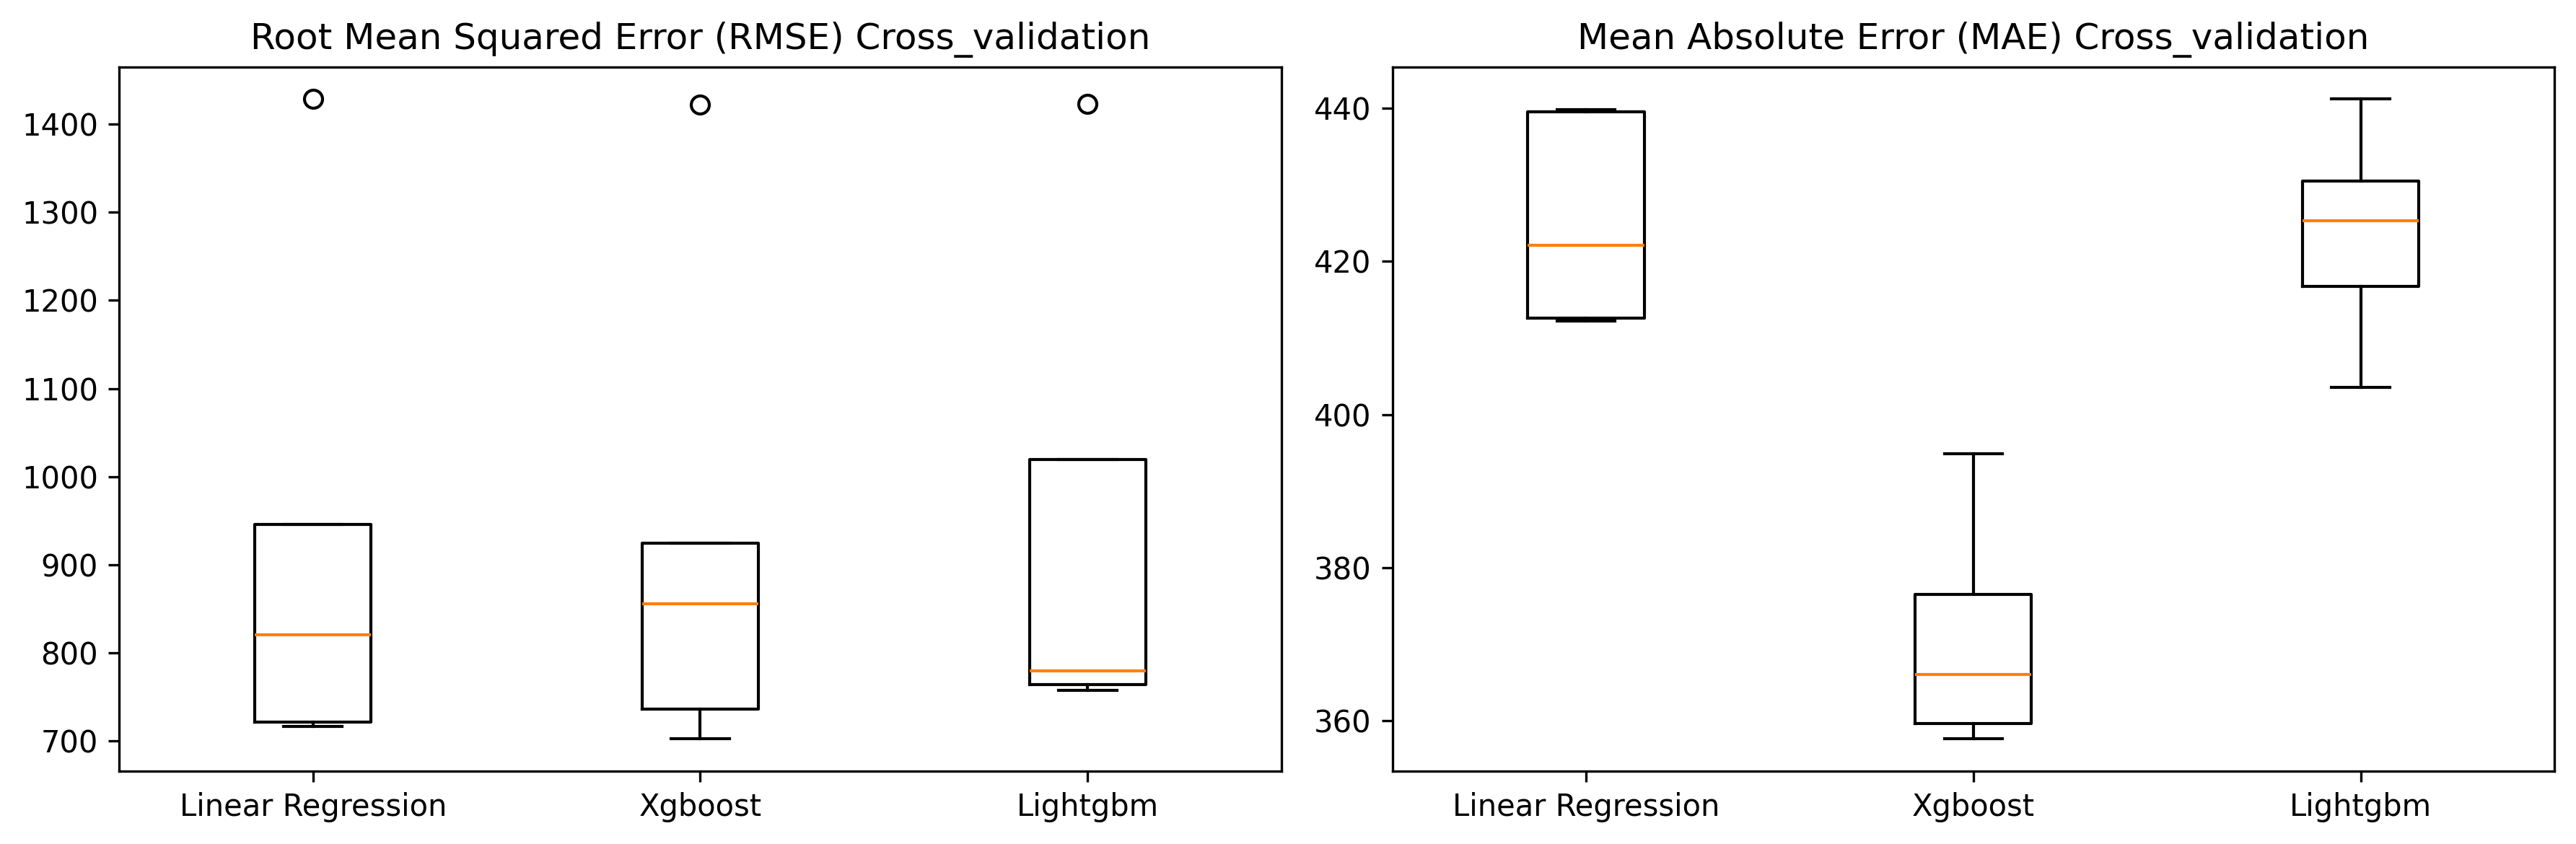

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.pipeline import make_pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.decomposition import PCA

from sklearn.model_selection import GroupShuffleSplit

from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler

gss = GroupShuffleSplit(n_splits = 1, train_size = 0.80, random_state = 42)

features_df = features_df.drop("CohortMonth", axis =1)
features_df = pd.get_dummies(features_df, drop_first = True)

train_idx, test_idx = next(
    gss.split(features_df, groups = features_df["CustomerID"]))

train_data = features_df.iloc[train_idx]
test_data = features_df.iloc[test_idx]

X_train = train_data.drop(["CustomerID","TargetRevenue"], axis = 1)
X_test = test_data.drop(["CustomerID","TargetRevenue"], axis =1 )

y_train = train_data["TargetRevenue"]
y_test = test_data["TargetRevenue"]

scaler = StandardScaler()

pca = PCA(n_components= 2)

models = [
   ("Linear Regression", LinearRegression()),
   ("Xgboost", XGBRegressor(n_estimators = 200, max_depth = 6, learning_rate = 0.5, random_state = 42)),
   ("Lightgbm", LGBMRegressor(n_estimators = 200, max_depth = 6, learning_rate = 0.5, random_state = 42))
   #("Random Forest", RandomForestRegressor(n_estimators = 200, max_depth = 6, min_samples_leaf = 2, random_state = 42))
]

rmse = []
mae = []
model_name = []

for name, model in models:
    wrapped_model = TransformedTargetRegressor(
    regressor = model,
    func = np.log1p,
    inverse_func = np.expm1)


    pipeline = make_pipeline(scaler, model)
    kf = KFold(n_splits = 5, shuffle = True, random_state = 42)
    cv_rmse = cross_val_score(pipeline, X_train, y_train, cv = kf, n_jobs = -1, scoring = "neg_root_mean_squared_error")
    cv_mae = cross_val_score(pipeline, X_train, y_train, cv = kf, n_jobs = -1, scoring = "neg_mean_absolute_error")

    rmse.append(-cv_rmse)
    mae.append(-cv_mae)
    model_name.append(name)



    print('\n')
    print(f'Number of Records Evaluated: {len(X_train)}')
    print(f'{name} Root Mean Squared Error (RMSE): {-cv_rmse}')
    print(f'{name} Mean Absolute Error (MAE): {-cv_mae}')

fig, (ax1, ax2) = plt.subplots(1,2, figsize = (12,4), dpi = 300)
ax1.boxplot(rmse, labels = model_name)
ax1.set_title("Root Mean Squared Error (RMSE) Cross_validation")
ax2.boxplot(mae, labels = model_name)
ax2.set_title("Mean Absolute Error (MAE) Cross_validation")
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:41:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "n_esimators" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


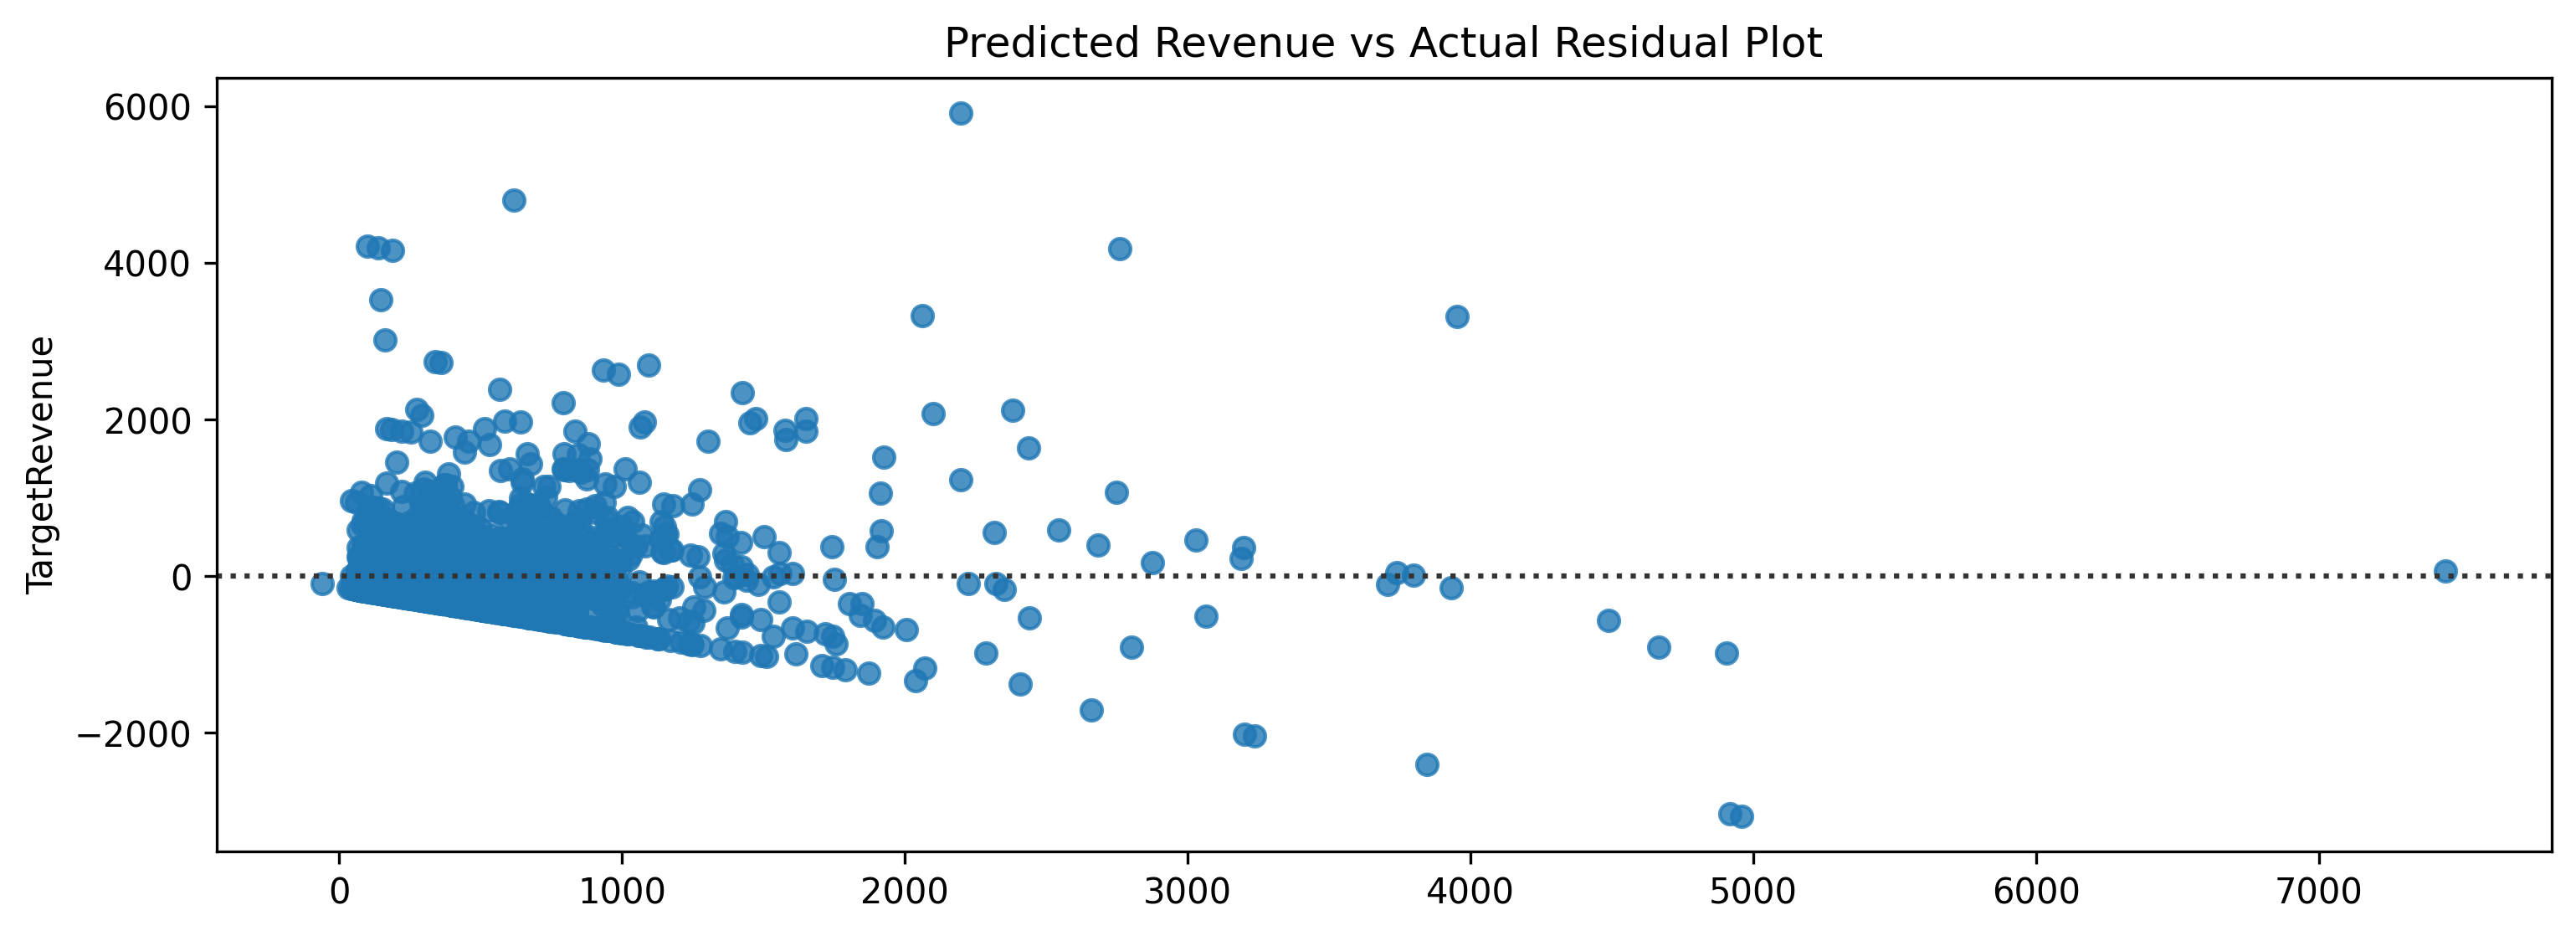

MAE:  378.26, RMSE:  611.32


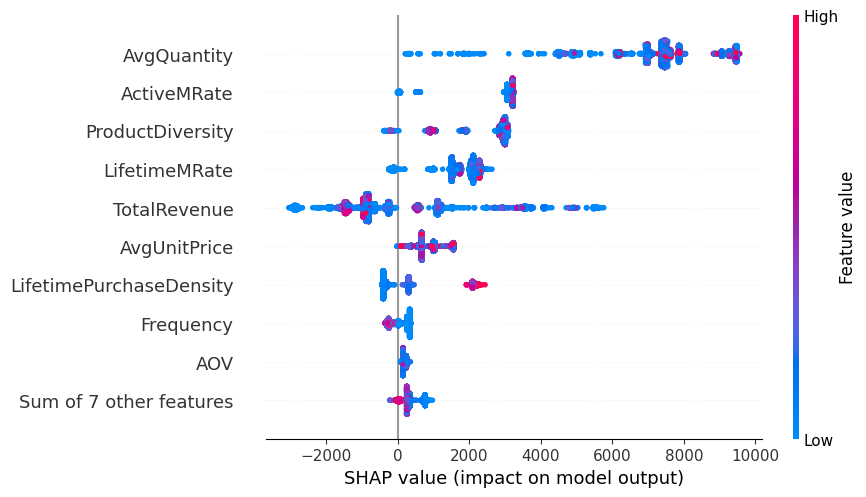

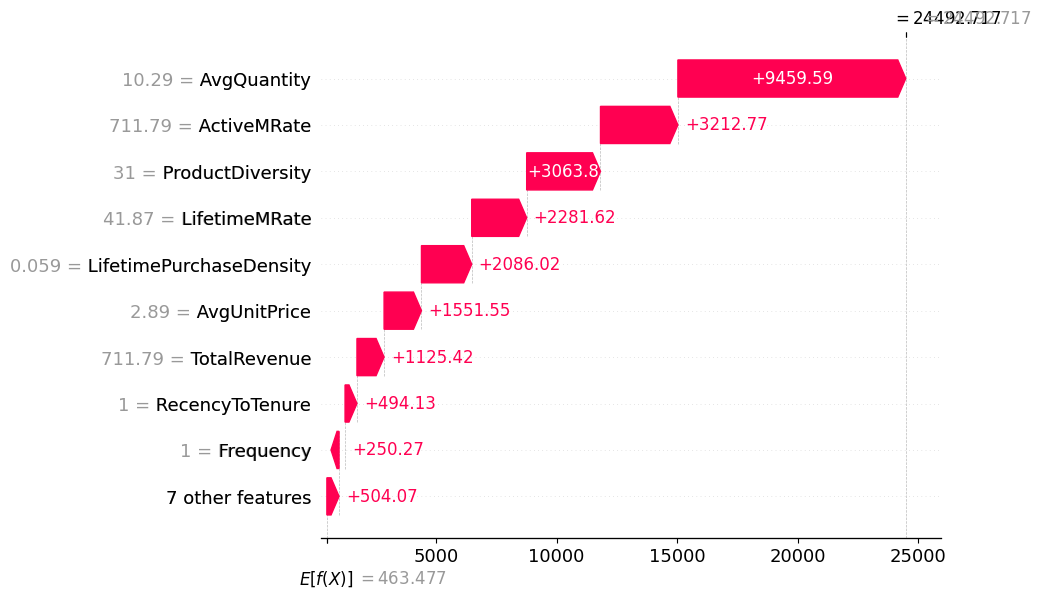

In [75]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

model = XGBRegressor(n_esimators = 200, max_depth = 6, learning_rate = 0.05, random_state = 42)
wrapped_model = TransformedTargetRegressor(
    regressor = model,
    func = np.log1p,
    inverse_func = np.expm1)

pipeline = make_pipeline(scaler, model)
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

plt.figure(figsize = (12,4), dpi = 300)
sns.residplot(x = y_pred, y = y_test)
plt.title('Predicted Revenue vs Actual Residual Plot')
plt.show()

test_data = X_test.copy()
test_data['ActualRevenue'] =  y_test
test_data['PredictedRevenue'] = y_pred
print(f'MAE: {mae: .2f}, RMSE: {rmse: .2f}')

import matplotlib.pyplot as plt
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_train)  # or X_test

shap.plots.beeswarm(shap_values, max_display=10)

plt.clf()

shap.plots.waterfall(shap_values[0], max_display=10)